# 🚨 Kredi Kartı Sahtekârlık Tespiti - COPOD Analizi

**Veri Seti:** [Credit Card Fraud Detection (Kaggle)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Yöntem:** COPOD (Copula-Based Outlier Detection)  
**Amaç:** Kredi kartı işlemlerindeki sahtekârlık (anomali) tespiti  

---

**Veri Seti Özellikleri:**
- 284,807 işlem kaydı
- 31 özellik (V1-V28: PCA ile indirgenmiş, Time, Amount, Class)
- Sadece %0.172 oranında sahtekârlık (ciddi dengesizlik var)

**Not:** Bu notebook Google Colab'da çalışacak şekilde tasarlanmıştır.

## 1. Gerekli Kütüphanelerin Yüklenmesi

In [1]:
!pip install pyod opendatasets -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.6/413.6 kB 14.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pyod.models.copod import COPOD
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)
import opendatasets as od

print('✅ Tüm kütüphaneler yüklendi!')

✅ Tüm kütüphaneler yüklendi!


## 2. Veri Setinin Yüklenmesi

In [3]:
od.download('https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud')

df = pd.read_csv('creditcardfraud/creditcard.csv')
print(f'Veri seti boyutu: {df.shape}')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: https://www.kaggle.com/gamzedrn
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


100%|██████████| 66.0M/66.0M [00:00<00:00, 118MB/s]



Veri seti boyutu: (284807, 31)


In [4]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [5]:
print('📊 Veri Seti Özeti:')
print(f'Toplam işlem sayısı: {len(df):,}')
print(f'Özellik sayısı: {df.shape[1]}')
print(f'Eksik değer sayısı: {df.isnull().sum().sum()}')
print()
print('Sınıf Dağılımı (Class):')
print(f'  Normal (0): {(df["Class"] == 0).sum():,} ({(df["Class"] == 0).mean()*100:.3f}%)')
print(f'  Sahtekârlık (1): {(df["Class"] == 1).sum():,} ({(df["Class"] == 1).mean()*100:.3f}%)')

📊 Veri Seti Özeti:
Toplam işlem sayısı: 284,807
Özellik sayısı: 31
Eksik değer sayısı: 0

Sınıf Dağılımı (Class):
  Normal (0): 284,315 (99.827%)
  Sahtekârlık (1): 492 (0.173%)


## 3. Keşifçi Veri Analizi (EDA)

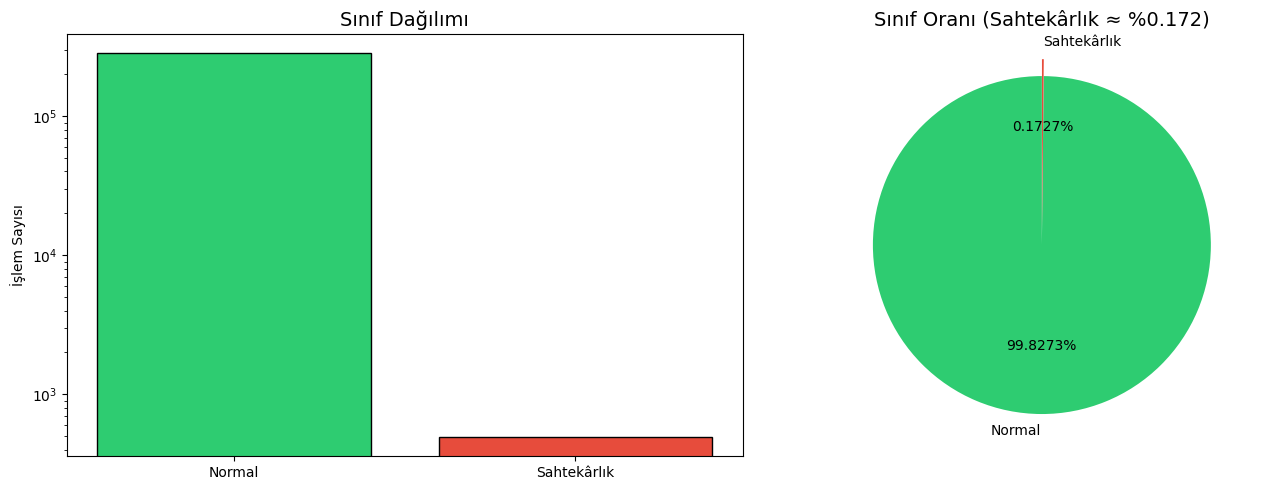


⚠️ Ciddi sınıf dengesizliği var - sahtekârlık çok nadir!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['Class'].value_counts()
axes[0].bar(['Normal', 'Sahtekârlık'], class_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Sınıf Dağılımı', fontsize=14)
axes[0].set_ylabel('İşlem Sayısı')
axes[0].set_yscale('log')

axes[1].pie(class_counts.values, labels=['Normal', 'Sahtekârlık'],
            autopct='%1.4f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Sınıf Oranı (Sahtekârlık ≈ %0.172)', fontsize=14)

plt.tight_layout()
plt.show()
print('\n⚠️ Ciddi sınıf dengesizliği var - sahtekârlık çok nadir!')

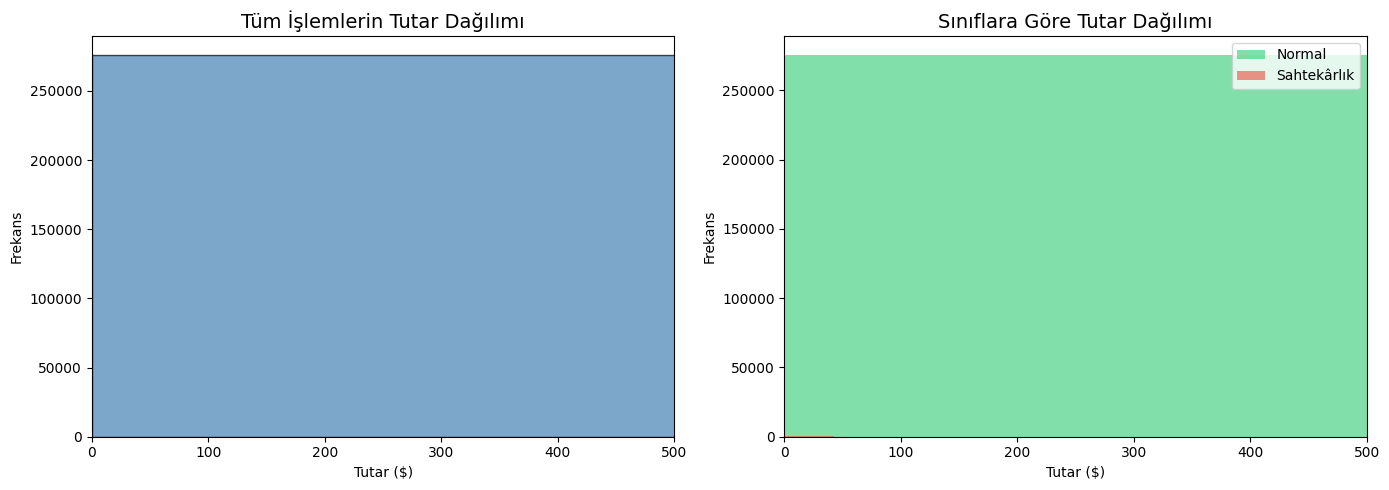

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Tüm İşlemlerin Tutar Dağılımı', fontsize=14)
axes[0].set_xlabel('Tutar ($)')
axes[0].set_ylabel('Frekans')
axes[0].set_xlim([0, 500])

axes[1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6,
             label='Normal', color='#2ecc71')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6,
             label='Sahtekârlık', color='#e74c3c')
axes[1].set_title('Sınıflara Göre Tutar Dağılımı', fontsize=14)
axes[1].set_xlabel('Tutar ($)')
axes[1].set_ylabel('Frekans')
axes[1].set_xlim([0, 500])
axes[1].legend()

plt.tight_layout()
plt.show()

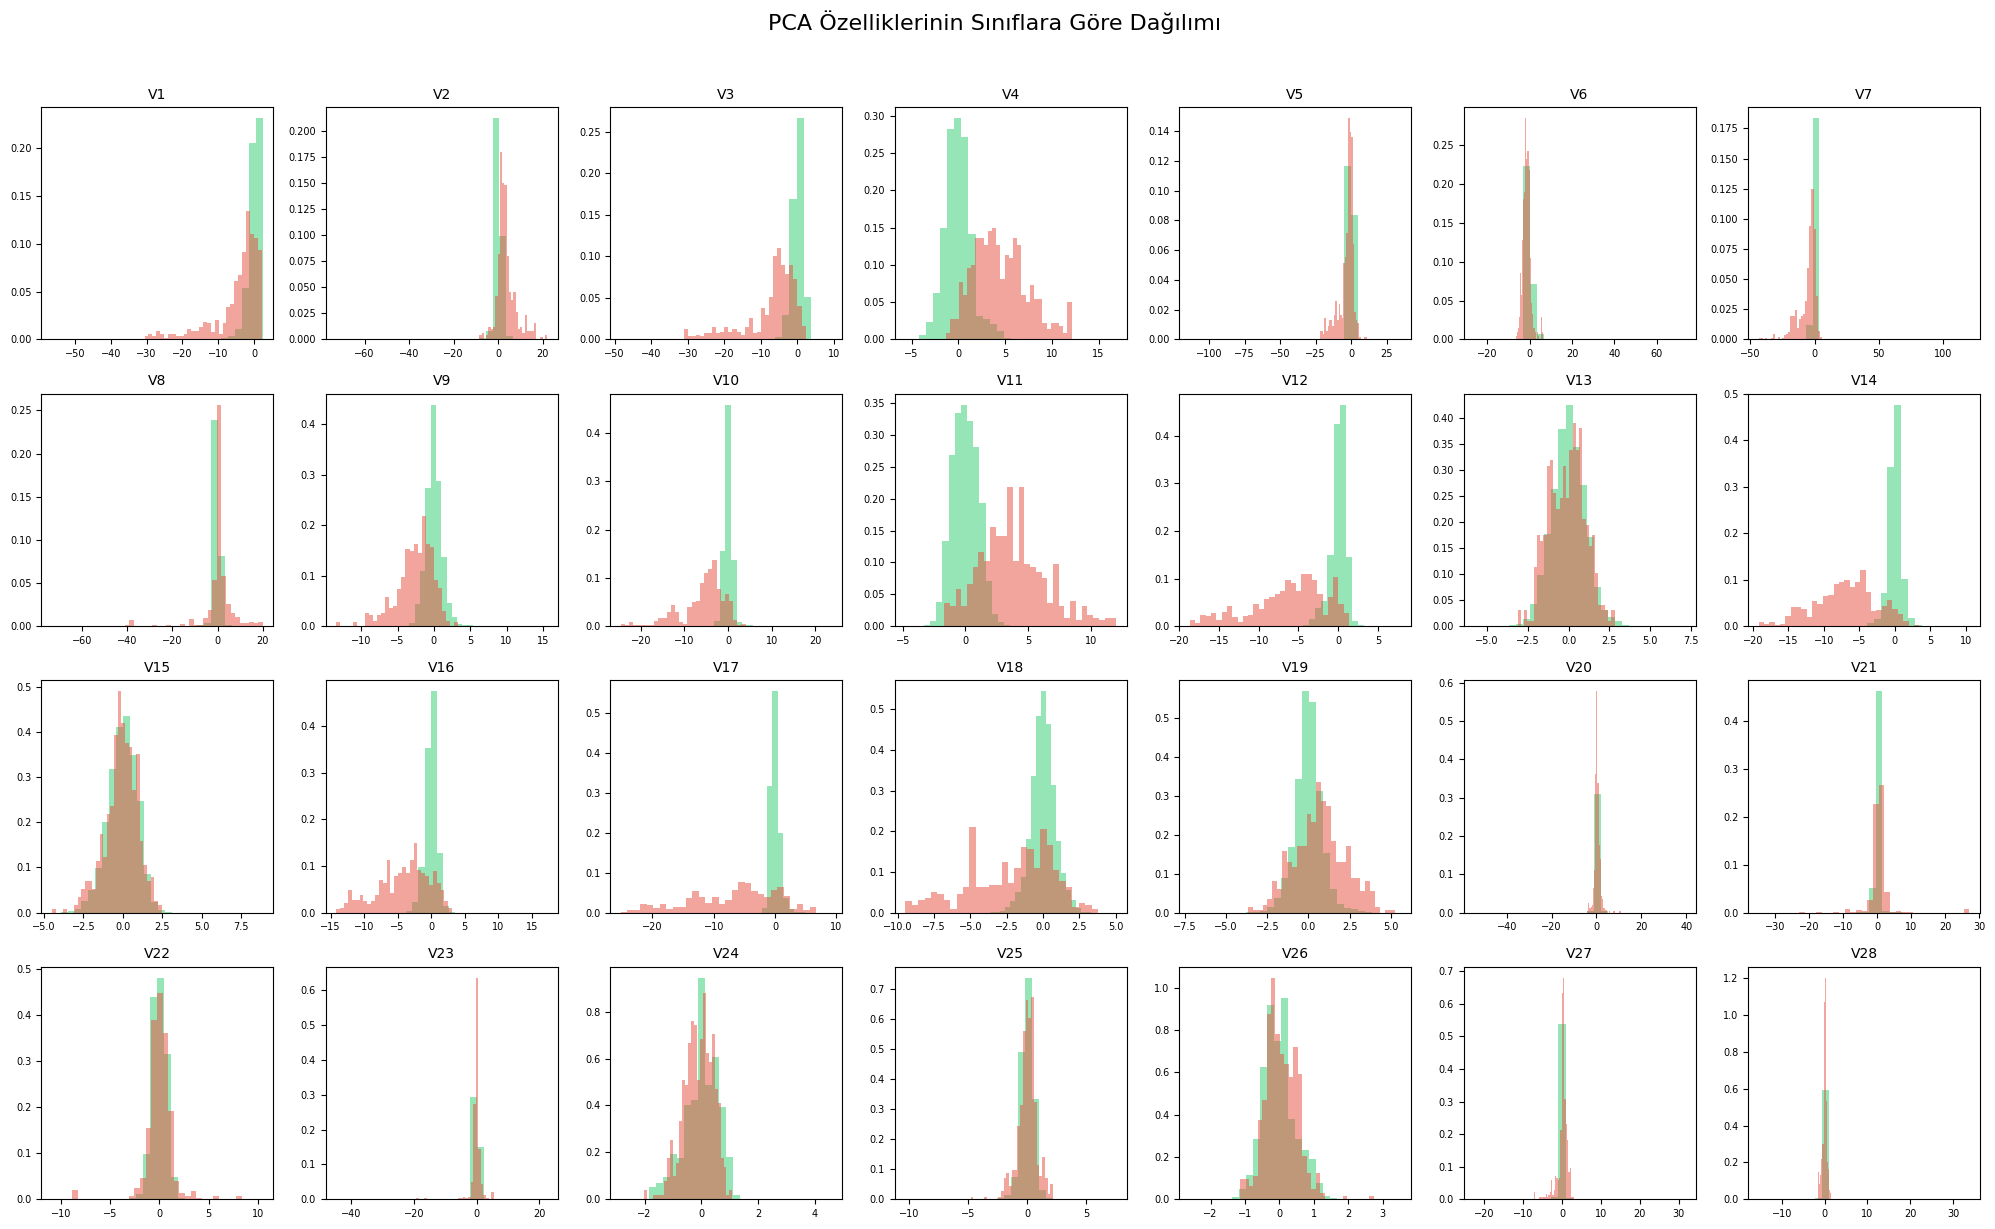

In [8]:
pca_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(4, 7, figsize=(20, 12))
axes = axes.ravel()

for i, feat in enumerate(pca_features):
    axes[i].hist(df[df['Class']==0][feat], bins=30, alpha=0.5,
                 label='Normal', color='#2ecc71', density=True)
    axes[i].hist(df[df['Class']==1][feat], bins=30, alpha=0.5,
                 label='Sahtekârlık', color='#e74c3c', density=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].tick_params(labelsize=7)

plt.suptitle('PCA Özelliklerinin Sınıflara Göre Dağılımı', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

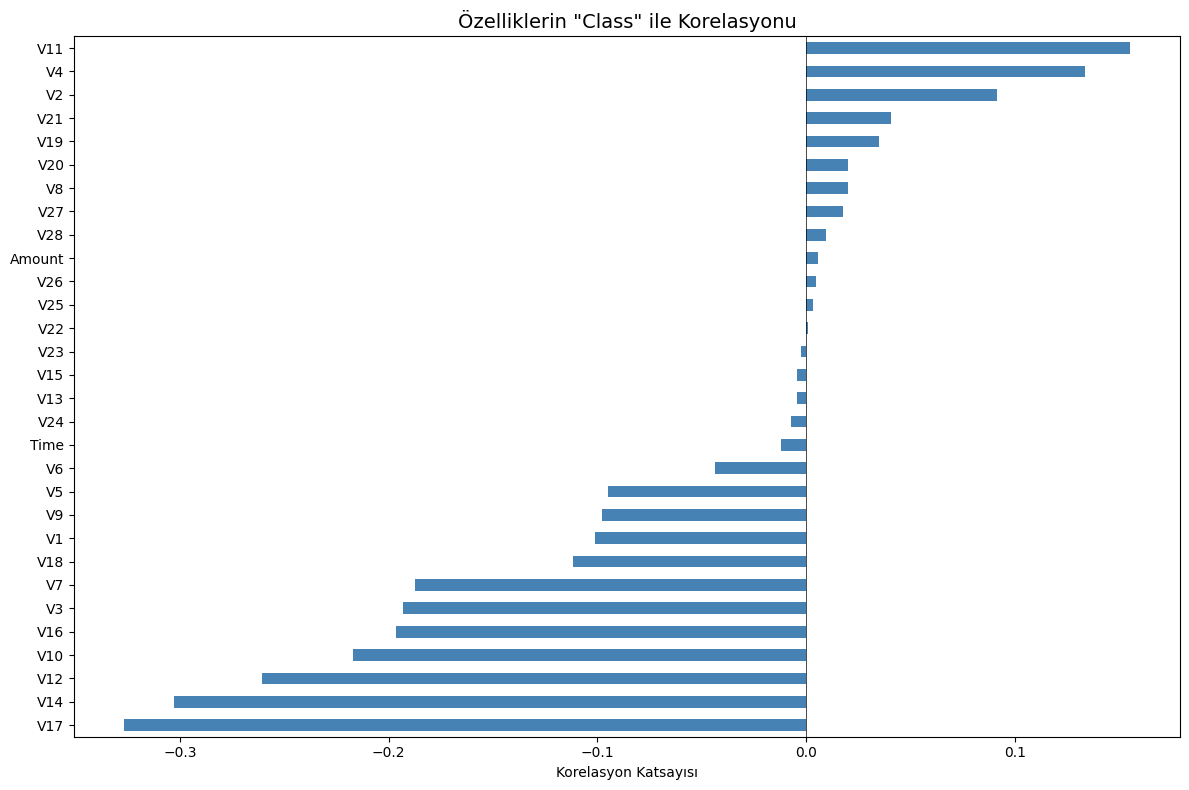

In [9]:
corr_with_class = df.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
corr_with_class.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Özelliklerin "Class" ile Korelasyonu', fontsize=14)
ax.set_xlabel('Korelasyon Katsayısı')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## 4. Veri Ön İşleme

In [10]:
y_true = df['Class'].values
X = df.drop(['Class', 'Time'], axis=1).copy()

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

print(f'Özellik matrisi boyutu: {X.shape}')
print(f'Hedef değişken boyutu: {y_true.shape}')
print(f'\nSahtekârlık oranı: {y_true.mean()*100:.4f}%')

Özellik matrisi boyutu: (284807, 29)
Hedef değişken boyutu: (284807,)

Sahtekârlık oranı: 0.1727%


In [11]:
X_normal = X[y_true == 0]
X_fraud = X[y_true == 1]

print(f'Normal işlem sayısı: {len(X_normal):,}')
print(f'Sahtekârlık işlem sayısı: {len(X_fraud):,}')

Normal işlem sayısı: 284,315
Sahtekârlık işlem sayısı: 492


## 5. COPOD Modeli Eğitimi

**COPOD** (Copula-Based Outlier Detection):
- Parametrik olmayan bir anomaly detection yöntemidir
- Her veri noktası için copula tabanlı bir outlier skoru hesaplar
- Verilerin dağılımını modellemeden çalışır
- Genellikle high-dimensional verilerde başarılıdır

In [12]:
print('🔍 COPOD modeli eğitiliyor...')
print(f'   Toplam veri: {len(X):,}')
print(f'   Anomali oranı (beklenen): %{y_true.mean()*100:.3f}')
print()

clf = COPOD(
    contamination=0.002
)

clf.fit(X)
print('✅ COPOD modeli eğitimi tamamlandı!')

🔍 COPOD modeli eğitiliyor...
   Toplam veri: 284,807
   Anomali oranı (beklenen): %0.173

✅ COPOD modeli eğitimi tamamlandı!


## 6. Tahminler ve Değerlendirme

In [13]:
y_scores = clf.decision_scores_
y_pred = clf.labels_

print('📊 Tahmin Sonuçları:')
print(f'   Tahmin edilen anomali sayısı: {sum(y_pred == 1):,}')
print(f'   Gerçek anomali sayısı: {sum(y_true == 1):,}')
print()

cm = confusion_matrix(y_true, y_pred)
print('Karışıklık Matrisi:')
print(f'  True Negatif  (Normal → Normal): {cm[0,0]:,}')
print(f'  False Pozitif (Normal → Anomali): {cm[0,1]:,}')
print(f'  False Negatif (Anomali → Normal): {cm[1,0]:,}')
print(f'  True Pozitif  (Anomali → Anomali): {cm[1,1]:,}')

📊 Tahmin Sonuçları:
   Tahmin edilen anomali sayısı: 570
   Gerçek anomali sayısı: 492

Karışıklık Matrisi:
  True Negatif  (Normal → Normal): 283,931
  False Pozitif (Normal → Anomali): 384
  False Negatif (Anomali → Normal): 306
  True Pozitif  (Anomali → Anomali): 186


In [14]:
print('📋 Sınıflandırma Raporu:')
print('='*60)
print(classification_report(y_true, y_pred,
                            target_names=['Normal', 'Sahtekârlık']))

roc_auc = roc_auc_score(y_true, y_scores)
print(f'\n🎯 ROC-AUC Skoru: {roc_auc:.4f}')

📋 Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
 Sahtekârlık       0.33      0.38      0.35       492

    accuracy                           1.00    284807
   macro avg       0.66      0.69      0.67    284807
weighted avg       1.00      1.00      1.00    284807


🎯 ROC-AUC Skoru: 0.9475


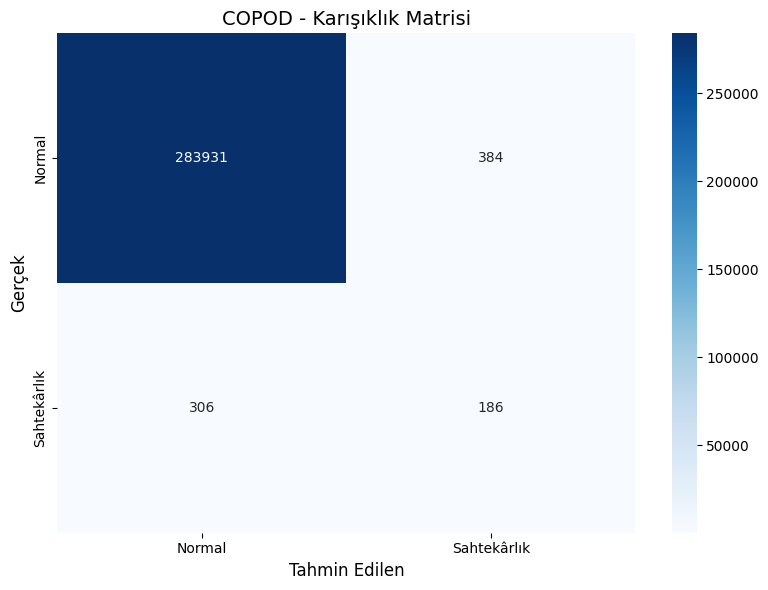

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Sahtekârlık'],
            yticklabels=['Normal', 'Sahtekârlık'])
ax.set_xlabel('Tahmin Edilen', fontsize=12)
ax.set_ylabel('Gerçek', fontsize=12)
ax.set_title('COPOD - Karışıklık Matrisi', fontsize=14)
plt.tight_layout()
plt.show()

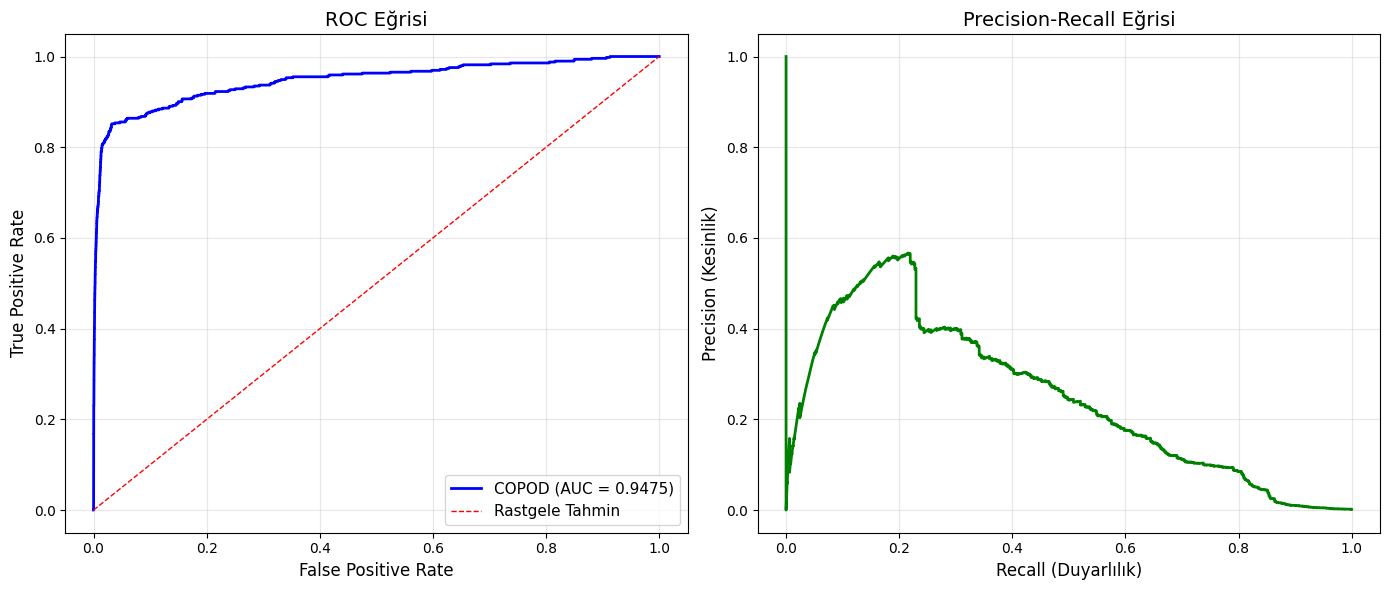

In [16]:
fpr, tpr, _ = roc_curve(y_true, y_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'COPOD (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Rastgele Tahmin')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Eğrisi', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

precision, recall, _ = precision_recall_curve(y_true, y_scores)
axes[1].plot(recall, precision, 'g-', linewidth=2)
axes[1].set_xlabel('Recall (Duyarlılık)', fontsize=12)
axes[1].set_ylabel('Precision (Kesinlik)', fontsize=12)
axes[1].set_title('Precision-Recall Eğrisi', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

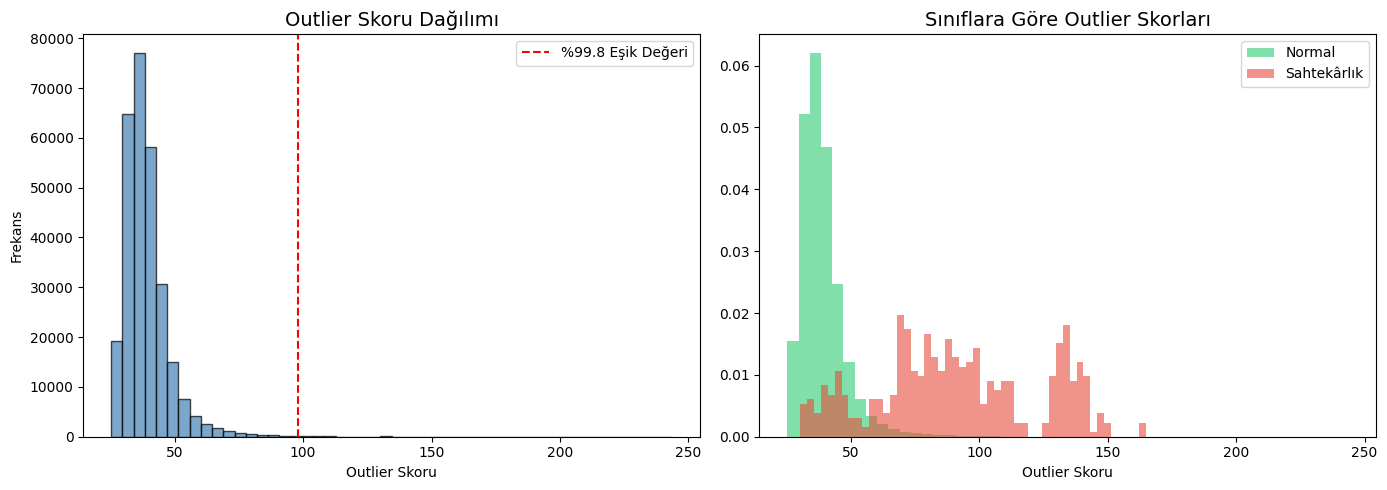

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_scores, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=np.percentile(y_scores, 99.8), color='red', linestyle='--',
                label='%99.8 Eşik Değeri')
axes[0].set_title('Outlier Skoru Dağılımı', fontsize=14)
axes[0].set_xlabel('Outlier Skoru')
axes[0].set_ylabel('Frekans')
axes[0].legend()

axes[1].hist(y_scores[y_true==0], bins=50, alpha=0.6,
             label='Normal', color='#2ecc71', density=True)
axes[1].hist(y_scores[y_true==1], bins=50, alpha=0.6,
             label='Sahtekârlık', color='#e74c3c', density=True)
axes[1].set_title('Sınıflara Göre Outlier Skorları', fontsize=14)
axes[1].set_xlabel('Outlier Skoru')
axes[1].legend()

plt.tight_layout()
plt.show()

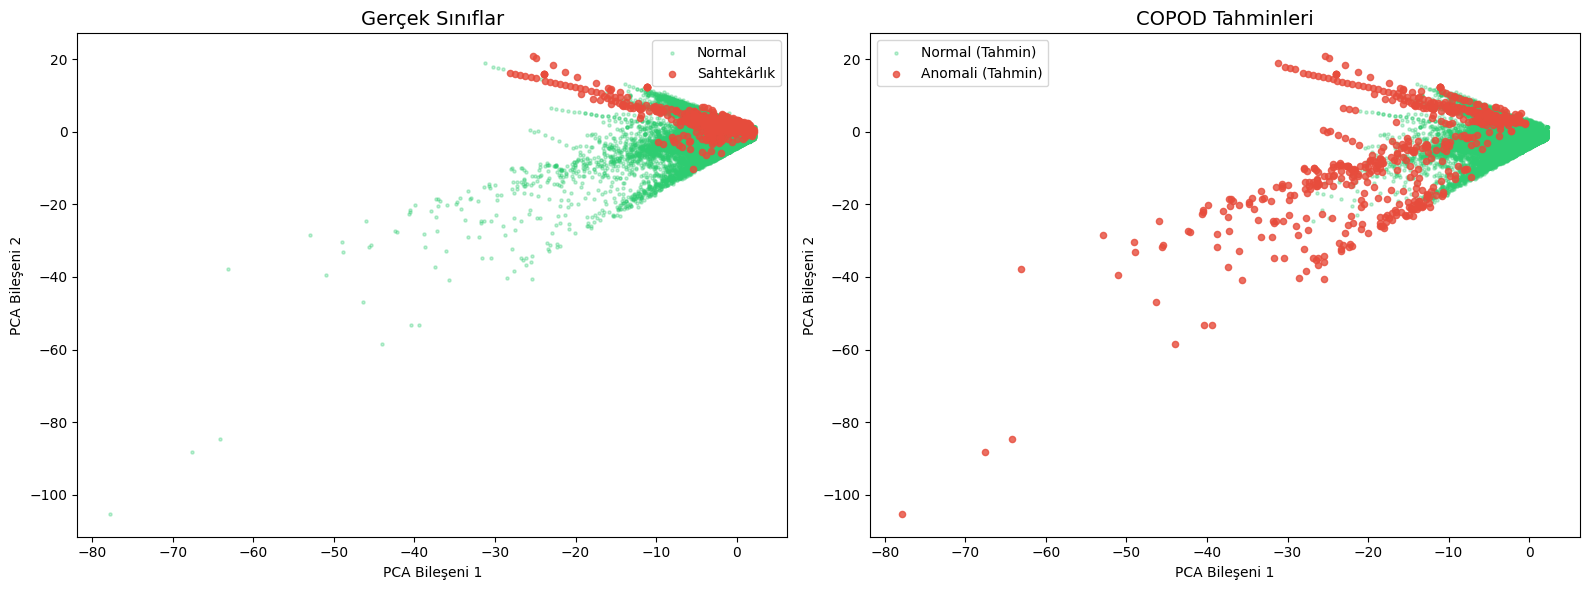

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca[y_true==0, 0], X_pca[y_true==0, 1],
               c='#2ecc71', alpha=0.3, s=5, label='Normal')
axes[0].scatter(X_pca[y_true==1, 0], X_pca[y_true==1, 1],
               c='#e74c3c', alpha=0.8, s=20, label='Sahtekârlık')
axes[0].set_title('Gerçek Sınıflar', fontsize=14)
axes[0].set_xlabel('PCA Bileşeni 1')
axes[0].set_ylabel('PCA Bileşeni 2')
axes[0].legend()

axes[1].scatter(X_pca[y_pred==0, 0], X_pca[y_pred==0, 1],
               c='#2ecc71', alpha=0.3, s=5, label='Normal (Tahmin)')
axes[1].scatter(X_pca[y_pred==1, 0], X_pca[y_pred==1, 1],
               c='#e74c3c', alpha=0.8, s=20, label='Anomali (Tahmin)')
axes[1].set_title('COPOD Tahminleri', fontsize=14)
axes[1].set_xlabel('PCA Bileşeni 1')
axes[1].set_ylabel('PCA Bileşeni 2')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Sonuçlar ve Yorumlama

### COPOD Modelinin Avantajları:
- Parametrik varsayım gerektirmez
- Yüksek boyutlu verilerde başarılıdır
- Hızlı eğitim süresi

### Credit Card Fraud Veri Seti İçin Bulgular:
- Ciddi sınıf dengesizliği var (%0.172 sahtekârlık)
- COPOD, PCA ile indirgenmiş özelliklerde başarılı sonuçlar verir
- Outlier skorları, gerçek sahtekârlık vakalarını iyi ayırt eder

### İyileştirme Önerileri:
1. Eşik değeri optimize et: contamination parametresini ayarla
2. Özellik mühendisliği: Yeni özellikler türet (Time-based, Amount-based)
3. Ensemble: COPOD ile birlikte diğer yöntemleri de kullan
4. Cross-validation: K-fold cross-validation ile daha güvenilir değerlendirme

In [19]:
df_results = df.copy()
df_results['outlier_score'] = y_scores
df_results['predicted_anomaly'] = y_pred

print('🔍 En Şüpheli 10 İşlem:')
print('='*80)
top_suspicious = df_results.nlargest(10, 'outlier_score')[
    ['Amount', 'Class', 'outlier_score', 'predicted_anomaly']
]
print(top_suspicious.to_string(index=False))

🔍 En Şüpheli 10 İşlem:
  Amount  Class  outlier_score  predicted_anomaly
25691.16      0     243.630302                  1
 5964.95      0     195.955365                  1
19656.53      0     195.839522                  1
18910.00      0     194.984687                  1
 4861.64      0     182.114219                  1
 1676.60      0     181.560404                  1
  303.80      0     178.610842                  1
 1201.83      0     176.759526                  1
 1676.60      0     174.493736                  1
 4543.64      0     171.000152                  1


In [20]:
print('📊 Farklı Eşik Değerlerinin Etkisi:')
print('='*60)
print(f'{"Eşik":>10} | {"Tespit Edilen":>15} | {"Precision":>10} | {"Recall":>10}')
print('-'*60)

for threshold in [0.99, 0.995, 0.999]:
    threshold_value = np.percentile(y_scores, threshold * 100)
    y_pred_thresh = (y_scores >= threshold_value).astype(int)

    tp = np.sum((y_pred_thresh == 1) & (y_true == 1))
    fp = np.sum((y_pred_thresh == 1) & (y_true == 0))
    fn = np.sum((y_pred_thresh == 0) & (y_true == 1))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f'%{threshold*100:>9.1f} | {sum(y_pred_thresh == 1):>15,} | {precision:>10.4f} | {recall:>10.4f}')

📊 Farklı Eşik Değerlerinin Etkisi:
      Eşik |   Tespit Edilen |  Precision |     Recall
------------------------------------------------------------
%     99.0 |           2,849 |     0.1193 |     0.6911
%     99.5 |           1,425 |     0.1979 |     0.5732
%     99.9 |             285 |     0.4070 |     0.2358
